In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# <span style="color:red"> ch9. Transformers </span>
- 인코더 층만으로 구현(입력:자연어 / 출력 : 긍정/부정(자연어가 아님)

# 1. 패키지

In [2]:

import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, MultiHeadAttention, Normalization
from time import time # 70.01.01부터 현재까지의 밀리세컨

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# 2. 하이퍼 파라미터 설정 
- 이 파라미터를 바꾸면 정확도나 학습 속도에 영향을 미침. 주로 반비례 관계로 영향을 줌

In [3]:
MY_WORDS = 10000  # imdb 데이터에서 가져올 단어 개수
MY_LENGTH = 170    # 영화평 단어수 80개만 독립변수
MY_EMBED = 128     # 임베딩 레이어의 결과 차원
MY_HIDDEN = 64    # 히든레이어의 유닛수
# FIT
MY_EPOCH = 30     # 학습 수
MY_BATCH = 200    # 배치사이즈

# 3. 데이터 불러오기

In [4]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MY_WORDS)

# 4. 문자단어 -> 정수

In [5]:
# 데이터들은 모두 숫자로 되어있으니, 우리는 무슨 말인지 궁금하다. 변환해보자
word_to_id = imdb.get_word_index()  # 각 단어와 숫자의 매칭 정보가 담긴 딕셔너리
id_to_word = {}
for word, idx in word_to_id.items():
    id_to_word[idx] = word
id_to_word

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

# 5. 숫자영화평 -> 자연어 영화평

In [8]:
def decoding(review_num):
    decoded = [id_to_word.get(d-3, '???') for d in review_num]
    return ' '.join(decoded)

In [9]:
print(y_train[1], decoding(x_train[1]))

0 ??? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal ??? the hair is big lots of boobs ??? men wear those cut ??? shirts that show off their ??? sickening that men actually wore them and the music is just ??? trash that plays over and over again in almost every scene there is trashy music boobs and ??? taking away bodies and the gym still doesn't close for ??? all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then


# 6. 영화평 (입력변수)의 길이

In [10]:
def show_length(x_train):
    print('영화평 단어개수')
    print([len(x_data) for x_data in x_train[:20]])
show_length(x_train)

영화평 단어개수
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177]


# 7. 모든 영화평 길이를 동일하게 (80)

In [11]:
X_train = pad_sequences(x_train,
                       padding='post',  # maxlen보다 데이터 량이 작으면, 'pre' 앞에 0을 채움, 'post' 뒤에 0을 채운
                       truncating='post',  # maxlen보다 데이터 량이 많으면 'post' 뒷부분을 자르고 앞부분을 남김, 'pre' 앞을 자름
                       maxlen=MY_LENGTH)
X_test =  pad_sequences(x_test,
                       padding='post',  # 앞에서 부터 채움
                       truncating='post',  # 뒷부분을 자르고 앞부분을 남김
                       maxlen=MY_LENGTH)
show_length(X_train), show_length(X_test)

영화평 단어개수
[170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170]
영화평 단어개수
[170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170]


(None, None)

# 8. 최종 데이터 shape 확인

In [20]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 170), (25000,), (25000, 170), (25000,))

In [21]:
MY_WORDS, MY_EMBED, MY_HIDDEN, MY_LENGTH

(10000, 128, 64, 170)

# 9. 모델 생성 - Transformers

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model

# 인풋층
INPUTS = layers.Input(shape=(MY_LENGTH,)) # 80
INPUT_EMBEDDING = layers.Embedding(input_dim=MY_WORDS, # 10000
                                   output_dim=MY_EMBED)(INPUTS) # 32
# Positional Encoding
POSITIONS = tf.range(start=0,
                    limit=MY_LENGTH)
POS_ENCODING = layers.Embedding(input_dim=MY_LENGTH, output_dim=MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING
ATTENTION_OUTPUT = layers.MultiHeadAttention(num_heads=3,
                                            key_dim=MY_EMBED)(POS_ENC_OUTPUT,
                                                        POS_ENC_OUTPUT)
X = layers.add([POS_ENC_OUTPUT, ATTENTION_OUTPUT])
X = layers.BatchNormalization()(X)

# FeedForward Network
FFN = Sequential([layers.Dense(MY_HIDDEN, activation="relu"),
layers.Dense(MY_EMBED, activation="relu")])(X)
X = layers.add([FFN, X])
X = layers.BatchNormalization()(X)

# 하나의 벡터로 압축해서 Dense로 보내줌
X = layers.GlobalAveragePooling1D()(X)
X = layers.Dropout(0.1)(X)
X = layers.Dense(MY_HIDDEN, activation="relu")(X)
X = layers.Dropout(0.1)(X)

OUTPUTS = layers.Dense(2, activation="softmax")(X)
model = Model(inputs=INPUTS, outputs=OUTPUTS)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 170)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 170, 128)     1280000     ['input_1[0][0]']                
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 170, 128)    0           ['embedding[0][0]']              
 da)                                                                                              
                                                                                                  
 multi_head_attention (MultiHea  (None, 170, 128)    197888      ['tf.__operators__.add[0][0]'

In [22]:
#LSTM (참고)
model = Sequential()
model.add(Embedding(input_dim=MY_WORDS,
                   output_dim=MY_EMBED,
                   input_length=MY_LENGTH))
# RNN : 입력 단어의 길이 수가 너무 길면 파리미터 업데이트 안 됨
# 개선모델1. LSTM 개선모델2. GRU
model.add(LSTM(MY_HIDDEN,
              input_shape=(MY_LENGTH, MY_EMBED)
              ))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 170, 128)          1280000   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 1,329,473
Trainable params: 1,329,473
Non-trainable params: 0
_________________________________________________________________


# 10. 학습환경 설정 및 실행

In [13]:

model.compile( # loss='binary_crossentropy',
              loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['acc'])
begin = time()
print(begin)
hist = model.fit(X_train, y_train,
                epochs=MY_EPOCH,
                batch_size=MY_BATCH,
                validation_split=0.3,
                verbose=1,
                )
end = time()
print('총 학습시간 :', end-begin, '초')

1750733990.867091
Epoch 1/30
88/88 [==============================] - 125s 1s/step - loss: 0.4513 - acc: 0.7771 - val_loss: 0.6203 - val_acc: 0.5572
Epoch 2/30
88/88 [==============================] - 131s 1s/step - loss: 0.2324 - acc: 0.9079 - val_loss: 0.6073 - val_acc: 0.5715
Epoch 3/30
88/88 [==============================] - 126s 1s/step - loss: 0.1692 - acc: 0.9343 - val_loss: 0.5671 - val_acc: 0.6511
Epoch 4/30
88/88 [==============================] - 128s 1s/step - loss: 0.1226 - acc: 0.9522 - val_loss: 0.4914 - val_acc: 0.7495
Epoch 5/30
88/88 [==============================] - 139s 2s/step - loss: 0.0899 - acc: 0.9646 - val_loss: 0.4993 - val_acc: 0.8112
Epoch 6/30
88/88 [==============================] - 132s 2s/step - loss: 0.0727 - acc: 0.9705 - val_loss: 0.5919 - val_acc: 0.8279
Epoch 7/30
88/88 [==============================] - 131s 1s/step - loss: 0.0570 - acc: 0.9775 - val_loss: 0.6594 - val_acc: 0.8353
Epoch 8/30
88/88 [==============================] - 138s 2s/step 

KeyboardInterrupt: 

# 11. 평가하기

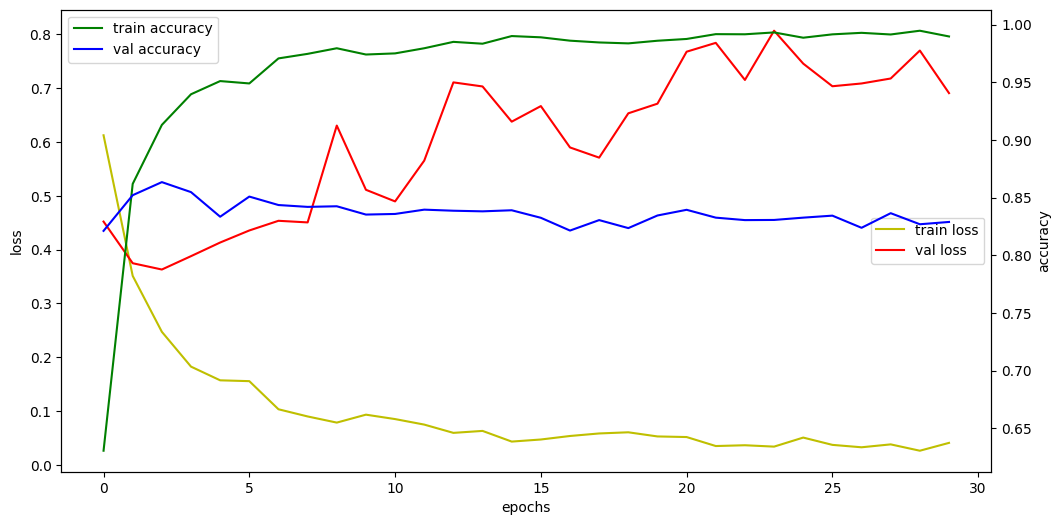

In [24]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['acc'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_acc'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [25]:
loss, acc = model.evaluate(X_test, y_test)
print('정확도 :', acc)

782/782 [==============================] - 19s 24ms/step - loss: 0.7636 - acc: 0.8135
정확도 : 0.813480019569397


In [26]:
# 혼동행렬, recall, precision을 위한 yhat
yhat = (model.predict(X_test,
                     verbose=1) > 0.5)

782/782 [==============================] - 19s 24ms/step
